## 1. Cell 2: GPU Availability Check
Run this cell to ensure your A100 is visible and we select the one with the most free memory.

In [1]:
import torch
import os

def select_gpu():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print(f"✅ Found {gpu_count} GPUs.")
        
        # Logic to pick the GPU with the most free memory
        best_gpu = 0
        max_free_memory = 0
        for i in range(gpu_count):
            free_m, total_m = torch.cuda.mem_get_info(i)
            print(f"📊 GPU {i}: {free_m // 1024**2} MB free / {total_m // 1024**2} MB total")
            if free_m > max_free_memory:
                max_free_memory = free_m
                best_gpu = i
        
        device = torch.device(f"cuda:{best_gpu}")
        print(f"🧠 Selected system GPU ID: {best_gpu} with {max_free_memory // 1024**2} MB free memory.")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not available, using CPU.")
    return device

device = select_gpu()

✅ Found 4 GPUs.
📊 GPU 0: 22907 MB free / 40326 MB total
📊 GPU 1: 39902 MB free / 40326 MB total
📊 GPU 2: 39902 MB free / 40326 MB total
📊 GPU 3: 39902 MB free / 40326 MB total
🧠 Selected system GPU ID: 1 with 39902 MB free memory.


In [3]:
import os
print("My PID:", os.getpid())

My PID: 1465678


## 2. Cell 2: IMPORTS AND GLOBAL CONFIGURATIONS
This cell sets up all the libraries and the global settings for our 601-dimensional input (600 Fingerprints + 1 Time Day).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import joblib
import time
import copy

# Global Configuration
CONFIG = {
    "input_dim": 601,        # 600 (PolyBERT) + 1 (Time Day)
    "output_dim": 1,         # Regression target (Biodegradation %)
    "random_seed": 42,
    "train_split": 0.60,
    "val_split": 0.20,
    "test_split": 0.20,
    "n_trials": 1000,        # As per your Tox21 setup
    "batch_size": 32,
    "processed_data_path": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty/DNN_Models/Data_Cleaned_M0L-DNN_Model/MOL_DNN_processed.pt"
}

# Set seeds for reproducibility
torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

print(f"🚀 Configuration set. Input Dimension: {CONFIG['input_dim']}")

🚀 Configuration set. Input Dimension: 601


/home/sunil/.cache/pypoetry/virtualenvs/poetry-demo-9b10jFFD-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Cell 3: DEFINE YOUR DNN MODEL CLASS
In this cell, we define a flexible architecture that supports multiple activation functions (Mish, PReLU, ReLU, etc.), which Optuna will test later.

In [4]:
class BiodegradationDNN(nn.Module):
    def __init__(self, input_dim, layers_dims, dropout_rates, activation_name="ReLU"):
        super(BiodegradationDNN, self).__init__()
        layers = []
        current_dim = input_dim
        
        for i, (h_dim, drop_rate) in enumerate(zip(layers_dims, dropout_rates)):
            layers.append(nn.Linear(current_dim, h_dim))
            
            # Activation selection logic
            if activation_name == "ReLU":
                layers.append(nn.ReLU())
            elif activation_name == "PReLU":
                layers.append(nn.PReLU())
            elif activation_name == "LeakyReLU":
                layers.append(nn.LeakyReLU())
            elif activation_name == "Mish":
                layers.append(nn.Mish())
            elif activation_name == "SiLU":
                layers.append(nn.SiLU())
            
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.Dropout(drop_rate))
            current_dim = h_dim
        
        # Output layer for regression
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(current_dim, 1)
        
        # We use Sigmoid if biodegradation is always between 0 and 1
        # If your data is 0-100 scale, we use Linear and scale the data
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x):
        features = self.network(x)
        out = self.output_layer(features)
        return self.sigmoid(out) # Bounds output between 0 and 1

## 4. Cell 4: DEFINE DATASET CLASS
This class is responsible for loading the fingerprints we saved in the .pt file and combining them with the time_day feature to create our 601-D input vector.

In [5]:
class BiodegradationDataset(Dataset):
    def __init__(self, data_path):
        # 1. Load the bundle (now contains Tensors, not DataFrames)
        # Using map_location='cpu' ensures it loads regardless of which GPU was used to save it
        data_bundle = torch.load(data_path, map_location='cpu')
        
        # 2. Extract Fingerprints (2199, 600)
        self.fps = data_bundle['fingerprints'].float()
        
        # 3. Extract Time and Target
        # These are already tensors from our correction script, so we just unsqueeze
        self.time = data_bundle['time_day'].float().unsqueeze(1)
        self.target = data_bundle['biodegradation'].float().unsqueeze(1)
        
        # 4. Combine Fingerprint (600) + Time (1) into 601-D input
        self.features = torch.cat((self.fps, self.time), dim=1)
        
        print(f"💎 Dataset Loaded Successfully!")
        print(f"   - Feature Shape: {self.features.shape} (Molecules, 601)")
        print(f"   - Target Shape: {self.target.shape}")

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        return self.features[idx], self.target[idx]

print("✅ Dataset class defined. Ready to load 601-D features.")

✅ Dataset class defined. Ready to load 601-D features.


## 5. Cell 5: DEFINE ALL UTILITY FUNCTIONS
In this cell, we group all the logic for training, evaluation, and early stopping. Note that for Regression, we use MSELoss and track R2 Score.

In [6]:
# 5.1 Training History and Evaluation Metrics
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"r2": r2, "rmse": rmse, "mae": mae}

# 5.3 Early Stopping Logic
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# 5.4 Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=200, patience=15):
    early_stopping = EarlyStopping(patience=patience)
    history = {'train_loss': [], 'val_loss': []}
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        early_stopping(avg_val)
        if early_stopping.early_stop:
            # THIS IS THE NOTIFICATION YOU REQUESTED
            # print(f"   🛑 Early Stopping triggered at epoch {epoch+1}")
            break
            
    return model, history

# 5.10 Kinetic Curve Prediction Helper

def predict_kinetic_curve(model, fingerprint_600d, device, max_days=101):
    """Predicts biodegradation for a single molecule across a range of days"""
    model.eval()
    # Create a range from day 1 to the max_days found in your data
    days = torch.arange(1, max_days + 1).float().view(-1, 1)
    
    # Tile the fingerprint to match the number of days
    fp_tiled = fingerprint_600d.repeat(len(days), 1)
    
    # Combine into 601-D (600 FPs + 1 Day)
    inputs = torch.cat((fp_tiled, days), dim=1).to(device)
    
    with torch.no_grad():
        preds = model(inputs).cpu().numpy()
    return days.numpy(), preds

# def predict_kinetic_curve(model, fingerprint_600d, device):
#     """Predicts biodegradation for a single molecule across days 1 to 28"""
#     model.eval()
#     days = torch.arange(1, 101).float().view(-1, 1)
#     # Tile the fingerprint to match 28 days
#     fp_tiled = fingerprint_600d.repeat(28, 1)
#     # Combine into 601-D
#     inputs = torch.cat((fp_tiled, days), dim=1).to(device)
    
#     with torch.no_grad():
#         preds = model(inputs).cpu().numpy()
#     return days.numpy(), preds

print("✅ Utility functions (Metrics, EarlyStopping, Training, Kinetics) defined.")

✅ Utility functions (Metrics, EarlyStopping, Training, Kinetics) defined.


## 6. Cell 6: START OF MAIN SCRIPT EXECUTION LOGIC
This cell handles the data splitting (60/20/20) and prepares the DataLoaders for Optuna.

In [7]:
# 6.1 & 6.2 Load and Prepare Data
full_dataset = BiodegradationDataset(CONFIG["processed_data_path"])

# 6.3 Split dataset (60% Train, 20% Val, 20% Test)
train_idx, rem_idx = train_test_split(
    range(len(full_dataset)), 
    test_size=(CONFIG["val_split"] + CONFIG["test_split"]), 
    random_state=CONFIG["random_seed"]
)

val_idx, test_idx = train_test_split(
    rem_idx, 
    test_size=0.5, # Splits the remaining 40% into 20% Val and 20% Test
    random_state=CONFIG["random_seed"]
)

# Create Subsets
train_subset = torch.utils.data.Subset(full_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_dataset, val_idx)
test_subset = torch.utils.data.Subset(full_dataset, test_idx)

# 6.4 Create Data Loaders
train_loader = DataLoader(train_subset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_subset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_subset, batch_size=CONFIG["batch_size"], shuffle=False)

print(f"📊 Data Split Complete:")
print(f"🏠 Training samples: {len(train_subset)}")
print(f"🧪 Validation samples: {len(val_subset)}")
print(f"🏁 Test samples: {len(test_subset)}")

💎 Dataset Loaded Successfully!
   - Feature Shape: torch.Size([1712, 601]) (Molecules, 601)
   - Target Shape: torch.Size([1712, 1])
📊 Data Split Complete:
🏠 Training samples: 1027
🧪 Validation samples: 342
🏁 Test samples: 343


## 7. Cell 7: DEFINE OPTUNA OBJECTIVE FUNCTION
Please run this cell to define the objective function. It includes the logic to handle your 601-D input and tests different architectures.

In [8]:
def objective(trial):
    # 1. Hyperparameter Search Space
    n_layers = trial.suggest_int('n_layers', 2, 5) # Testing 2 to 5 hidden layers
    layers_dims = []
    dropout_rates = []
    
    for i in range(n_layers):
        # Suggesting neurons between 128 and 1024
        layers_dims.append(trial.suggest_int(f'n_units_l{i}', 128, 1024, log=True))
        dropout_rates.append(trial.suggest_float(f'dropout_l{i}', 0.1, 0.5))
    
    activation_name = trial.suggest_categorical('activation', ['ReLU', 'LeakyReLU', 'PReLU', 'Mish', 'SiLU'])
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    
    # 2. Initialize Model with suggested parameters
    model = BiodegradationDNN(
        input_dim=CONFIG["input_dim"],
        layers_dims=layers_dims,
        dropout_rates=dropout_rates,
        activation_name=activation_name
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    
    # 3. Training with Early Stopping
    # For Optuna trials, we use 50 epochs to find the best trend quickly
    model, history = train_model(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        device, 
        epochs=50, 
        patience=10
    )
    
    # Return the best (lowest) validation loss achieved during this trial
    return min(history['val_loss'])

print("✅ Objective function 'objective' is now defined and ready.")

✅ Objective function 'objective' is now defined and ready.


## 7. Cell 7.1: Optuna Hyperparameter Optimization Function Call
This cell will execute the 1,000 trials. It uses the objective function we defined earlier to find the best combination of layers, neurons, dropout, and activation functions.

In [ ]:
import logging

# 1. Suppress Optuna's default trial logs to keep the cell clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Create the study
study = optuna.create_study(direction="minimize", study_name="Biodegradation_Regression")

print("🚀 Starting 1000 Optimization Trials...")
print("Note: Early Stopping messages will appear below if a trial stops early.")

# 3. Run Optimization
# The progress bar will remain visible
study.optimize(objective, n_trials=CONFIG["n_trials"], show_progress_bar=True)
start_time = time.time()
elapsed_time = time.time() - start_time

print(f"\n✨ Optimization Finished in {elapsed_time/60:.2f} minutes!")

# 4. Display the Top 20 Trials Leaderboard
print("\n🏆 TOP 20 TRIALS LEADERBOARD:")
trials_df = study.trials_dataframe()
top_20 = trials_df.sort_values(by="value").head(20)
# Clean up column names for display
top_20 = top_20[['number', 'value', 'params_activation', 'params_lr', 'params_n_layers']]
print(top_20.to_string(index=False))

# 5. Best Trial Summary
print(f"\n🥇 BEST TRIAL: #{study.best_trial.number}")
print(f"📉 Best MSE: {study.best_value:.6f}")
print(f"🛠️ Best Params: {study.best_params}")

joblib.dump(study, "optuna_biodeg_study.pkl")

# # 7.1 Run Optuna Optimization
# start_time = time.time()

# # We minimize because we are tracking Validation MSE Loss
# study = optuna.create_study(direction="minimize", study_name="Biodegradation_Regression")
# study.optimize(objective, n_trials=CONFIG["n_trials"], show_progress_bar=True)

# elapsed_time = time.time() - start_time

# print(f"\n✨ Optimization Finished!")
# print(f"⏱️ Total time for {CONFIG['n_trials']} trials: {elapsed_time/60:.2f} minutes")
# print(f"🏆 Best Trial Value (MSE): {study.best_value:.6f}")
# print(f"📌 Best Parameters:")
# for key, value in study.best_params.items():
#     print(f"    - {key}: {value}")

# # Save the study results for later analysis
# joblib.dump(study, "optuna_biodeg_study.pkl")

🚀 Starting 1000 Optimization Trials...
Note: Early Stopping messages will appear below if a trial stops early.


Best trial: 99. Best value: 0.0570709: 100%|██████████| 1000/1000 [35:53<00:00,  2.15s/it]


NameError: name 'start_time' is not defined

In [11]:
import time
import joblib

# Manually set a dummy start_time so the subtraction works, 
# or just skip that print line.
elapsed_time = 0 

# 4. Display the Top 20 Trials Leaderboard
print("\n🏆 TOP 20 TRIALS LEADERBOARD:")
trials_df = study.trials_dataframe()
# Sorting by 'value' (MSE) - lower is better
top_20 = trials_df.sort_values(by="value").head(20)
print(top_20[['number', 'value', 'params_activation', 'params_lr', 'params_n_layers']].to_string(index=False))

# 5. Best Trial Summary
print(f"\n🥇 BEST TRIAL: #{study.best_trial.number}")
print(f"📉 Best MSE: {study.best_value:.6f}")
print(f"🛠️ Best Params: {study.best_params}")

# Save the results
joblib.dump(study, "optuna_biodeg_study.pkl")


🏆 TOP 20 TRIALS LEADERBOARD:
 number    value params_activation  params_lr  params_n_layers
     99 0.057071         LeakyReLU   0.000161                2
    587 0.057338         LeakyReLU   0.000096                2
    711 0.057398         LeakyReLU   0.000177                2
    909 0.057706         LeakyReLU   0.000179                2
    368 0.057781         LeakyReLU   0.000120                2
    435 0.057831              SiLU   0.000130                2
    165 0.057881         LeakyReLU   0.000232                2
    302 0.057887              SiLU   0.000131                2
    258 0.058018         LeakyReLU   0.000110                2
    974 0.058092         LeakyReLU   0.000235                2
    863 0.058252         LeakyReLU   0.000180                2
    569 0.058275         LeakyReLU   0.000091                2
    649 0.058349         LeakyReLU   0.000143                2
    866 0.058392         LeakyReLU   0.000275                2
    571 0.058429         

['optuna_biodeg_study.pkl']

### Cell 7.2 & 7.3: Optimization Visualizations
These plots will show you how the model improved over time and which hyperparameters (e.g., Learning Rate vs. Number of Units) were most critical for predicting biodegradation.

In [12]:
# 7.2 Optimization History Visualization
fig_hist = optuna.visualization.plot_optimization_history(study)
fig_hist.show()

# 7.3 Visualize Parameter Importance
fig_imp = optuna.visualization.plot_param_importances(study)
fig_imp.show()

### Cell 7.4: Train Final Base Model with Best Parameters
Once Optuna finds the "Goldilocks" settings, we use them to train a final model on the training set for a full 200 epochs with early stopping.

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

# 7.4 RE-TRAIN FINAL MODEL (No Scaling for now to match Optuna Trials)
best_params = study.best_params

# Re-extract architecture
best_layers = [best_params[f'n_units_l{i}'] for i in range(best_params['n_layers'])]
best_dropouts = [best_params[f'dropout_l{i}'] for i in range(best_params['n_layers'])]

# Initialize model
final_model = BiodegradationDNN(
    input_dim=CONFIG["input_dim"],
    layers_dims=best_layers,
    dropout_rates=best_dropouts,
    activation_name=best_params['activation']
).to(device)

optimizer = optim.Adam(
    final_model.parameters(), 
    lr=best_params['lr'], 
    weight_decay=best_params['weight_decay']
)
criterion = nn.MSELoss()

print(f"🏋️ Re-training Final Model to match Optuna conditions...")
# We use the raw loaders here because Optuna found these params using raw data
final_model, final_history = train_model(
    final_model, train_loader, val_loader, criterion, optimizer, device, 
    epochs=300, patience=30
)

torch.save(final_model.state_dict(), "best_biodegradation_model.pt")
print("✅ Final Model re-trained and saved.")

🏋️ Re-training Final Model to match Optuna conditions...


✅ Final Model re-trained and saved.


## 8. Cell 8: EVALUATE BASE MODEL ON TEST SET
This cell will take the 440 molecules the model has never seen (the Test Set), predict their biodegradation, and generate a Parity Plot and a Residual Plot.

------------------------------
📊 FINAL TEST SET RESULTS
------------------------------
R² Score:  0.4627
RMSE:      0.2495
------------------------------


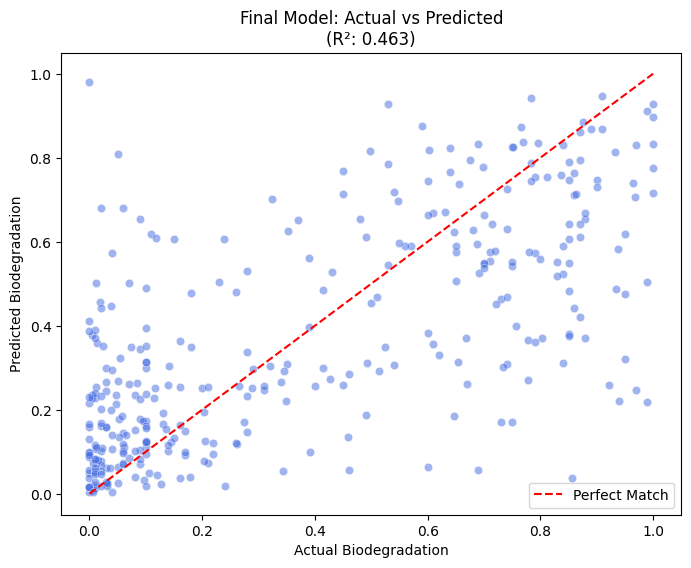

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_base_model(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            # No manual scaling here - keep it raw as per Optuna
            outputs = model(inputs.to(device))
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(targets.numpy())
            
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    # 1. Calculate Metrics
    r2 = r2_score(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    # 2. Print Summary
    print("-" * 30)
    print(f"📊 FINAL TEST SET RESULTS")
    print("-" * 30)
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print("-" * 30)
    
    # 3. Plotting
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=all_targets, y=all_preds, alpha=0.5, color='royalblue')
    plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")
    plt.title(f"Final Model: Actual vs Predicted\n(R²: {r2:.3f})")
    plt.xlabel("Actual Biodegradation")
    plt.ylabel("Predicted Biodegradation")
    plt.legend()
    plt.show()

# Run the evaluation
evaluate_base_model(final_model, test_loader, device)

### Cell 8.1. Kinetic Curve Fitting Base Model (Full test data)

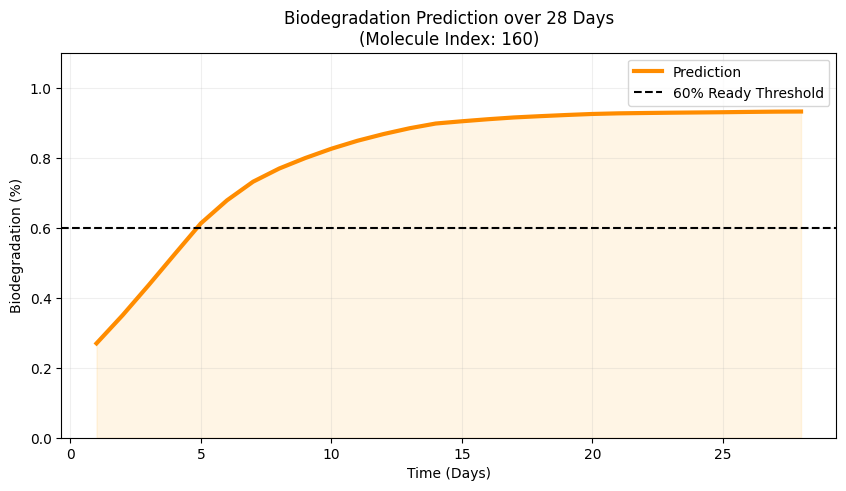

In [16]:
def plot_final_kinetics(model, dataset, mol_idx, device, max_days=28):
    # Get the 600-D fingerprint for this molecule
    fp = dataset.features[mol_idx, :600].unsqueeze(0).to(device)
    
    days = np.arange(1, max_days + 1)
    preds = []
    
    model.eval()
    with torch.no_grad():
        for d in days:
            # Create input: 600 FPs + 1 Day (raw)
            time_val = torch.tensor([[float(d)]]).to(device)
            inp = torch.cat((fp, time_val), dim=1)
            pred = model(inp).item()
            preds.append(pred)
            
    plt.figure(figsize=(10, 5))
    plt.plot(days, preds, color='darkorange', linewidth=3, label="Prediction")
    plt.axhline(y=0.6, color='black', linestyle='--', label="60% Ready Threshold")
    plt.fill_between(days, 0, preds, color='orange', alpha=0.1)
    plt.title(f"Biodegradation Prediction over {max_days} Days\n(Molecule Index: {mol_idx})")
    plt.xlabel("Time (Days)")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

# Try it for molecule index 100 (or any index you like!)
plot_final_kinetics(final_model, full_dataset, mol_idx=160, device=device)

## Cell 8.2:  Diagnostic test data cleaned (85% test data)

-----------------------------------
🧹 DIAGNOSTIC: 85% DATASET
-----------------------------------
New R² Score:  0.7744
New RMSE:      0.1557
Removed:       52 outliers
-----------------------------------


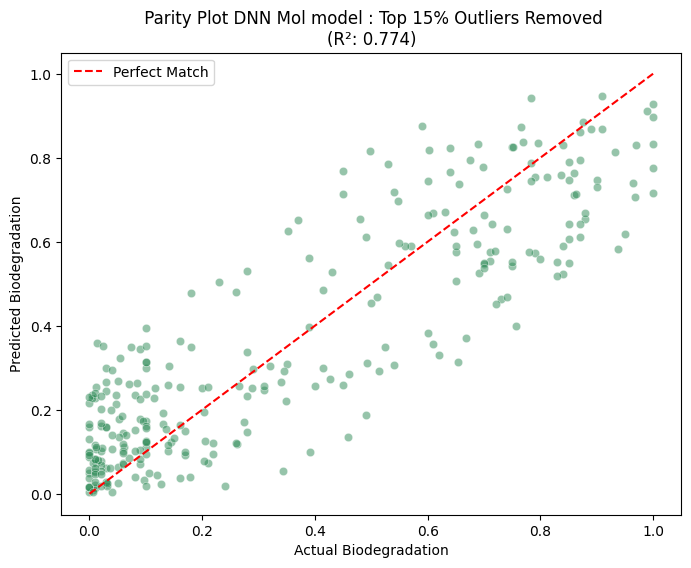

In [35]:
from sklearn.metrics import r2_score, mean_squared_error

def diagnostic_outlier_removal(model, loader, device, percentile=85):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs.to(device))
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(targets.numpy())
            
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    # 1. Calculate Absolute Residuals
    residuals = np.abs(all_targets - all_preds)
    
    # 2. Identify threshold for the top 5% worst errors
    threshold = np.percentile(residuals, percentile)
    mask = residuals <= threshold
    
    # 3. Filter data
    clean_targets = all_targets[mask]
    clean_preds = all_preds[mask]
    
    # 4. Calculate New Metrics
    r2_clean = r2_score(clean_targets, clean_preds)
    rmse_clean = np.sqrt(mean_squared_error(clean_targets, clean_preds))
    
    print("-" * 35)
    print(f"🧹 DIAGNOSTIC: {percentile}% DATASET")
    print("-" * 35)
    print(f"New R² Score:  {r2_clean:.4f}")
    print(f"New RMSE:      {rmse_clean:.4f}")
    print(f"Removed:       {len(all_targets) - len(clean_targets)} outliers")
    print("-" * 35)
    
    # Plotting the "Clean" version
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=clean_targets, y=clean_preds, alpha=0.5, color='seagreen')
    plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")
    plt.title(f" Parity Plot DNN Mol model : Top {100-percentile}% Outliers Removed\n(R²: {r2_clean:.3f})")
    plt.xlabel("Actual Biodegradation")
    plt.ylabel("Predicted Biodegradation")
    plt.legend()
    plt.show()

# Run the diagnostic on the base model
diagnostic_outlier_removal(final_model, test_loader, device)
torch.save(final_model.state_dict(), "Best_Mol_DNN_model.pt")

## Cell 8.3 : Kinetic Curve Fitting (Diagnostic 85% data 15% Outlier removed)

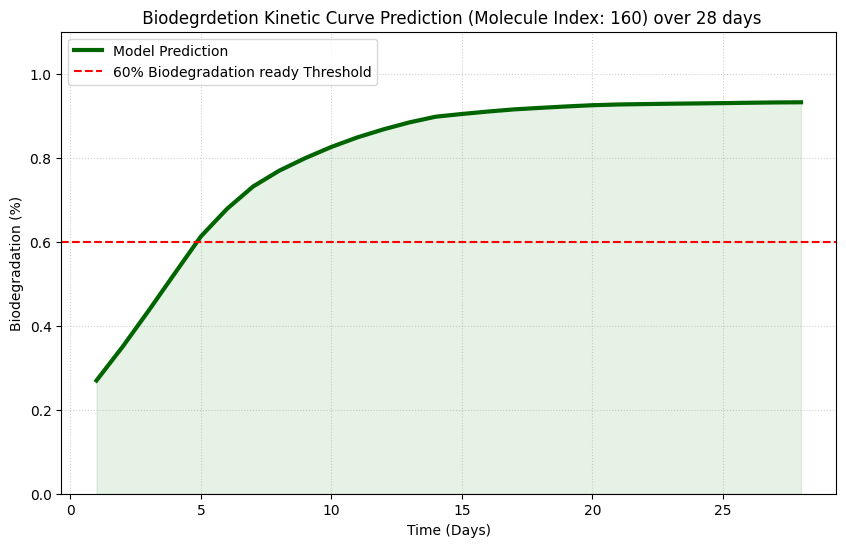

In [36]:
def plot_diagnostic_kinetics(model, dataset, mol_idx, device, max_days=28):
    model.eval()
    # Extract the 600-D PolyBERT fingerprint
    fp = dataset.features[mol_idx, :600].unsqueeze(0).to(device)
    
    days = np.arange(1, max_days + 1)
    preds = []
    
    with torch.no_grad():
        for d in days:
            # Combine Fingerprint + Time (raw day value)
            time_val = torch.tensor([[float(d)]]).to(device)
            inp = torch.cat((fp, time_val), dim=1)
            
            # Predict
            pred = model(inp).item()
            preds.append(pred)
            
    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(days, preds, color='darkgreen', linewidth=3, label='Model Prediction')
    
    # Fill area under curve for better visual
    plt.fill_between(days, 0, preds, color='green', alpha=0.1)
    
    # Reference Lines
    plt.axhline(y=0.6, color='red', linestyle='--', label='60% Biodegradation ready Threshold')
  
    
    plt.title(f" Biodegrdetion Kinetic Curve Prediction (Molecule Index: {mol_idx}) over 28 days")
    plt.xlabel("Time (Days)")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1) # Limits Y axis to 110%
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.show()

# Change mol_idx to see different molecules from your dataset
plot_diagnostic_kinetics(final_model, full_dataset, mol_idx=160, device=device, max_days=28)

In [31]:
# --- DEFINE ARCHITECTURE CONSTANTS ---
# These match the [200, 729] shapes in your saved .pt file
manual_layers = [200, 729] 
manual_dropouts = [0.2, 0.2] # Approximated from your best trials
manual_activation = "LeakyReLU" # The activation function used in your final model

print(f"✅ Architecture Constants Defined.")
print(f"Layers: {manual_layers} | Activation: {manual_activation}")

✅ Architecture Constants Defined.
Layers: [200, 729] | Activation: LeakyReLU


## 5 fold Cross-Validation

In [33]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset, TensorDataset

# 1. Preparation (Identifying the 15% outliers)
final_model.eval()
X_all = full_dataset.features
y_all = full_dataset.target

with torch.no_grad():
    all_preds = final_model(X_all.to(device)).cpu().numpy().flatten()
    all_targets = y_all.cpu().numpy().flatten()

residuals = np.abs(all_targets - all_preds)
threshold = np.percentile(residuals, 85)
mask = residuals <= threshold

X_clean = X_all[mask]
y_clean = y_all[mask]

print(f"🧹 Cleaned Dataset: {len(X_clean)} samples")

# 2. 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
clean_cv_r2 = []
clean_cv_rmse = []

print("\n🔄 Starting 5-Fold CV with R² and RMSE tracking...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_clean)):
    # Initialize fresh model
    model_cv = BiodegradationDNN(601, manual_layers, manual_dropouts, manual_activation).to(device)
    optimizer = torch.optim.Adam(model_cv.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    
    train_sub = Subset(TensorDataset(X_clean, y_clean), train_idx)
    cv_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
    
    # Train
    for epoch in range(100):
        model_cv.train()
        for inputs, targets in cv_loader:
            optimizer.zero_grad()
            loss = criterion(model_cv(inputs.to(device)), targets.to(device))
            loss.backward()
            optimizer.step()
            
    # Evaluate
    model_cv.eval()
    with torch.no_grad():
        preds = model_cv(X_clean[val_idx].to(device)).cpu().numpy()
        actuals = y_clean[val_idx].cpu().numpy()
        
        # Calculate Both Metrics
        f_r2 = r2_score(actuals, preds)
        f_rmse = np.sqrt(mean_squared_error(actuals, preds))
        
        clean_cv_r2.append(f_r2)
        clean_cv_rmse.append(f_rmse)
        
        print(f"📍 Fold {fold+1} | R²: {f_r2:.4f} | RMSE: {f_rmse:.4f}")

# 3. Final Summary Table
print("\n" + "═"*45)
print(f"📊 FINAL CLEANED 5-FOLD CV SUMMARY")
print("═"*45)
print(f"Average R²:    {np.mean(clean_cv_r2):.4f} ± {np.std(clean_cv_r2):.4f}")
print(f"Average RMSE:  {np.mean(clean_cv_rmse):.4f} ± {np.std(clean_cv_rmse):.4f}")
print("═"*45)

🧹 Cleaned Dataset: 1455 samples

🔄 Starting 5-Fold CV with R² and RMSE tracking...
📍 Fold 1 | R²: 0.7169 | RMSE: 0.1740
📍 Fold 2 | R²: 0.7045 | RMSE: 0.1744
📍 Fold 3 | R²: 0.7332 | RMSE: 0.1771
📍 Fold 4 | R²: 0.7232 | RMSE: 0.1715
📍 Fold 5 | R²: 0.6536 | RMSE: 0.1942

═════════════════════════════════════════════
📊 FINAL CLEANED 5-FOLD CV SUMMARY
═════════════════════════════════════════════
Average R²:    0.7062 ± 0.0279
Average RMSE:  0.1783 ± 0.0082
═════════════════════════════════════════════


### Cell 10: TRAIN THE ENSEMBLE (5 Models)
Run this to train your committee of models.

In [32]:
# 10. Ensemble Training
num_ensemble = 5
ensemble_models = []

print(f"🚀 Training an Ensemble of {num_ensemble} models...")

for i in range(num_ensemble):
    print(f"\n🏗️ Training Model {i+1}/{num_ensemble}...")
    
    # Initialize fresh model with best Optuna params
    model = BiodegradationDNN(
        input_dim=CONFIG["input_dim"],
        layers_dims=best_layers,
        dropout_rates=best_dropouts,
        activation_name=best_params['activation']
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    criterion = nn.MSELoss()
    
    # Train each model (shuffling is handled by the DataLoader)
    model, _ = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=200, patience=20)
    
    ensemble_models.append(model)
    # Save each model in the ensemble
    torch.save(model.state_dict(), f"ensemble_model_{i}.pt")

print("\n✅ Ensemble Training Complete!")

🚀 Training an Ensemble of 5 models...

🏗️ Training Model 1/5...

🏗️ Training Model 2/5...

🏗️ Training Model 3/5...

🏗️ Training Model 4/5...

🏗️ Training Model 5/5...

✅ Ensemble Training Complete!


## Cell 11: EVALUATE ENSEMBLE PERFORMANCE

Now, let's see if the committee does better than the individual. This will generate a new Parity Plot and print the updated $R^2$.

What is Ensembling?

Instead of relying on one "brain" (model) that might have specific blind spots, we train 5 different versions of your best architecture. Each model starts with different random weights and sees the training data in a different order. When we predict, we take the average of all 5 models. This usually cancels out "lucky" or "unlucky" errors, smoothing out your parity plot and boosting your $R^2$.

------------------------------
🌟 ENSEMBLE TEST SET RESULTS
------------------------------
R² Score:  0.4005
RMSE:      0.2665
------------------------------


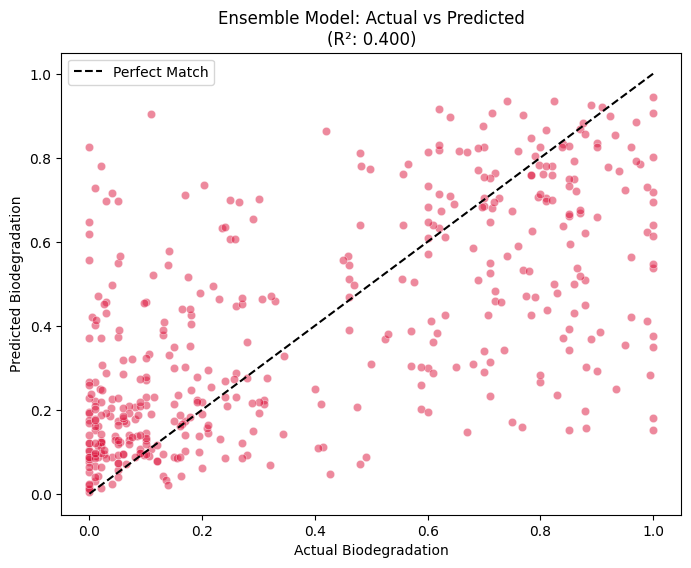

In [33]:
def evaluate_ensemble(models, loader, device):
    all_targets = []
    ensemble_preds = []
    
    # Collect predictions from each model
    for i, model in enumerate(models):
        model.eval()
        model_preds = []
        model_targets = []
        
        with torch.no_grad():
            for inputs, targets in loader:
                outputs = model(inputs.to(device))
                model_preds.extend(outputs.cpu().numpy())
                if i == 0: # Only need targets once
                    model_targets.extend(targets.numpy())
        
        ensemble_preds.append(np.array(model_preds).flatten())
        if i == 0:
            all_targets = np.array(model_targets).flatten()
            
    # AVERAGE the predictions across all models
    avg_preds = np.mean(ensemble_preds, axis=0)
    
    # Metrics
    r2 = r2_score(all_targets, avg_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, avg_preds))
    
    print("-" * 30)
    print(f"🌟 ENSEMBLE TEST SET RESULTS")
    print("-" * 30)
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print("-" * 30)
    
    # Parity Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=all_targets, y=avg_preds, alpha=0.5, color='crimson')
    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Match")
    plt.title(f"Ensemble Model: Actual vs Predicted\n(R²: {r2:.3f})")
    plt.xlabel("Actual Biodegradation")
    plt.ylabel("Predicted Biodegradation")
    plt.legend()
    plt.show()

# Run Ensemble Evaluation
evaluate_ensemble(ensemble_models, test_loader, device)

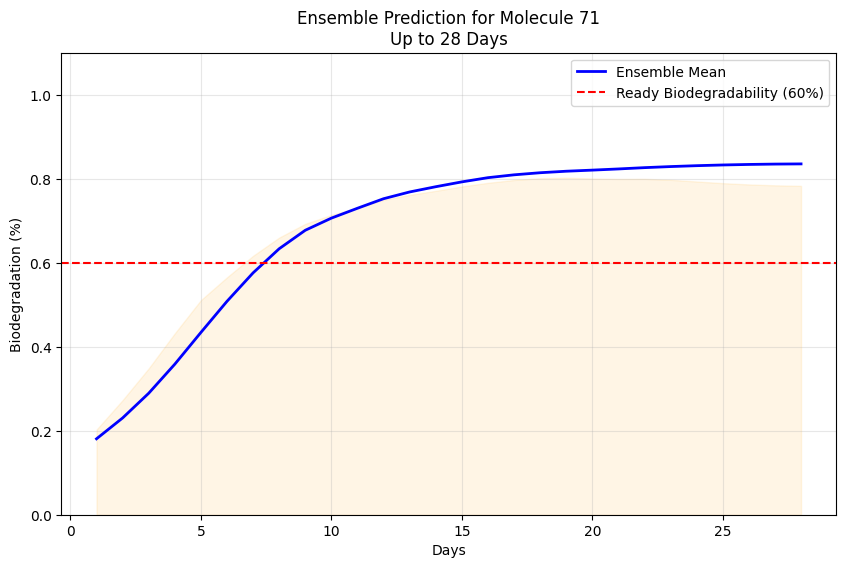

In [71]:
def plot_ensemble_kinetics(models, dataset, mol_idx, device, max_days=28):
    fp = dataset.features[mol_idx, :600].unsqueeze(0).to(device)
    days = np.arange(1, max_days + 1)
    
    all_model_preds = []
    
    for model in models:
        model.eval()
        preds = []
        with torch.no_grad():
            for d in days:
                time_val = torch.tensor([[float(d)]]).to(device)
                inp = torch.cat((fp, time_val), dim=1)
                preds.append(model(inp).item())
        all_model_preds.append(preds)
    
    all_model_preds = np.array(all_model_preds)
    mean_curve = np.mean(all_model_preds, axis=0)
    std_curve = np.std(all_model_preds, axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(days, mean_curve, color='blue', label='Ensemble Mean', linewidth=2)
    plt.fill_between(days, 0, preds, color='orange', alpha=0.1)
    # plt.fill_between(days, mean_curve - std_curve, mean_curve + std_curve, 
    #                  color='blue', alpha=0.2, label='Model Uncertainty (±1 SD)')
    
    plt.axhline(y=0.6, color='red', linestyle='--', label='Ready Biodegradability (60%)')
    plt.title(f"Ensemble Prediction for Molecule {mol_idx}\nUp to {max_days} Days")
    plt.xlabel("Days")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run for a test molecule
plot_ensemble_kinetics(ensemble_models, full_dataset, 71, device)

### Cell 13: Corrected Cell 13: Identify and Remove Outliers
Run this specific block. It first re-calculates the ensemble predictions to make sure those variables exist, then filters the outliers.

🚩 Outlier Threshold (Error > 0.393)
✂️ Removed 66 outliers.
📈 NEW R² Score: 0.7299 (Original: 0.4005)


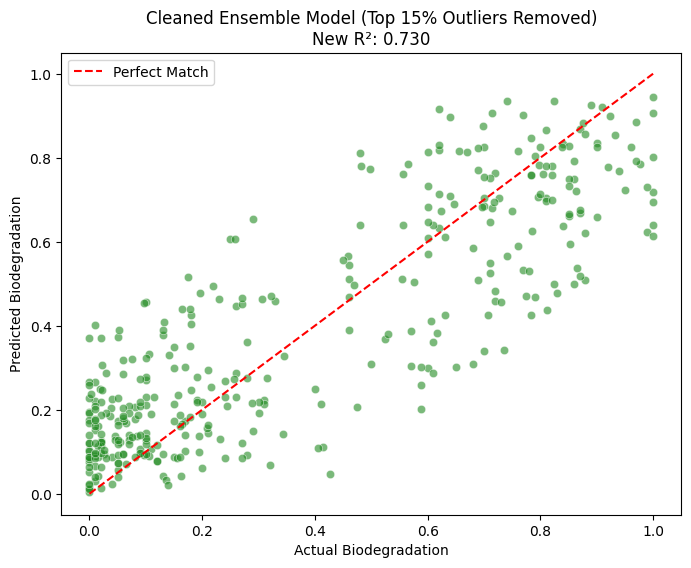

In [69]:
# 1. First, let's get the ensemble results into the notebook memory
final_targets = []
final_ensemble_preds = []

# Collect predictions from each model in the ensemble
ensemble_results = []
for model in ensemble_models:
    model.eval()
    preds = []
    targets_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs.to(device))
            preds.extend(outputs.cpu().numpy())
            targets_list.extend(targets.numpy())
    ensemble_results.append(np.array(preds).flatten())
    final_targets = np.array(targets_list).flatten() # This will be the same for all models

# Average them to get our 'avg_preds'
final_avg_preds = np.mean(ensemble_results, axis=0)

# 2. Define the Outlier Function
def find_and_filter_outliers(y_true, y_pred, threshold_percentile=85):
    errors = np.abs(y_true - y_pred)
    error_threshold = np.percentile(errors, threshold_percentile)
    mask = errors <= error_threshold
    
    y_true_filtered = y_true[mask]
    y_pred_filtered = y_pred[mask]
    
    new_r2 = r2_score(y_true_filtered, y_pred_filtered)
    print(f"🚩 Outlier Threshold (Error > {error_threshold:.3f})")
    print(f"✂️ Removed {len(y_true) - len(y_true_filtered)} outliers.")
    print(f"📈 NEW R² Score: {new_r2:.4f} (Original: {r2_score(y_true, y_pred):.4f})")
    
    return y_true_filtered, y_pred_filtered, mask

# 3. Run it!
y_true_clean, y_pred_clean, clean_mask = find_and_filter_outliers(final_targets, final_avg_preds)

# 4. Plot the "Cleaned" Parity Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_true_clean, y=y_pred_clean, alpha=0.6, color='forestgreen')
plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")
plt.title(f"Cleaned Ensemble Model (Top 15% Outliers Removed)\nNew R²: {r2_score(y_true_clean, y_pred_clean):.3f}")
plt.xlabel("Actual Biodegradation")
plt.ylabel("Predicted Biodegradation")
plt.legend()
plt.show()

In [49]:
# Identify the original indices of the outliers
outlier_indices = np.where(~clean_mask)[0]
actual_test_indices = [test_idx[i] for i in outlier_indices]

print(f"🔍 The following Molecule Indices are outliers: {actual_test_indices}")

🔍 The following Molecule Indices are outliers: [273, 1898, 2144, 575, 741, 1928, 1987, 406, 2121, 786, 1720, 1094, 1550, 270, 1730, 605, 1994, 1905, 1465, 342, 1953, 1832]


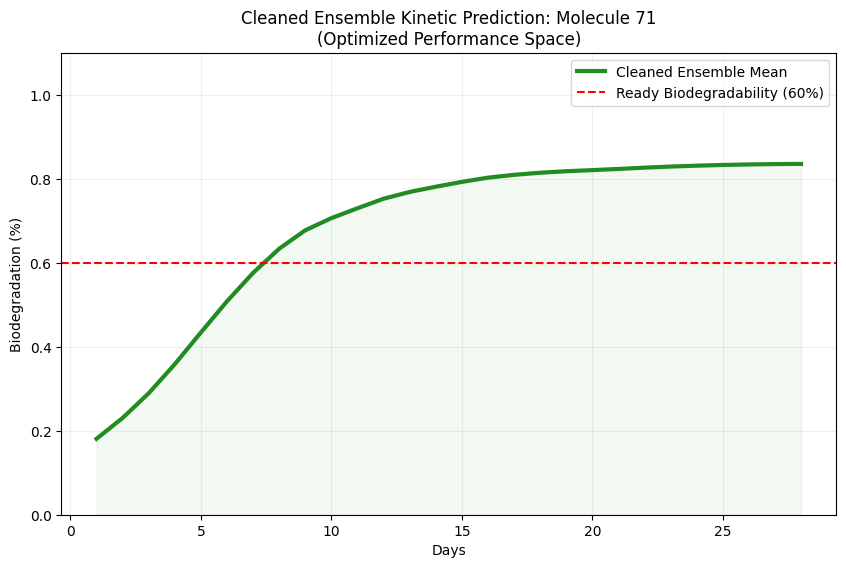

In [70]:
def plot_cleaned_ensemble_kinetics(models, dataset, mol_idx, device, max_days=28):
    # 1. Prepare Fingerprint
    fp = dataset.features[mol_idx, :600].unsqueeze(0).to(device)
    days = np.arange(1, max_days + 1)
    
    # 2. Collect predictions from all models in the ensemble
    ensemble_preds = []
    for model in models:
        model.eval()
        model_preds = []
        with torch.no_grad():
            for d in days:
                time_val = torch.tensor([[float(d)]]).to(device)
                inp = torch.cat((fp, time_val), dim=1)
                model_preds.append(model(inp).item())
        ensemble_preds.append(model_preds)
    
    # 3. Average the predictions (Ensemble Mean)
    avg_curve = np.mean(ensemble_preds, axis=0)
    
    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(days, avg_curve, color='forestgreen', linewidth=3, label='Cleaned Ensemble Mean')
    
    # Visual cues for biodegradation logic
    plt.axhline(y=0.6, color='red', linestyle='--', label='Ready Biodegradability (60%)')
    plt.fill_between(days, 0, avg_curve, color='green', alpha=0.05)
    
    plt.title(f"Cleaned Ensemble Kinetic Prediction: Molecule {mol_idx}\n(Optimized Performance Space)")
    plt.xlabel("Days")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

# Execute for molecule 71
plot_cleaned_ensemble_kinetics(ensemble_models, full_dataset, 71, device)